# Lab 2 · Tableau: Make a Chart That Does Not Lie

**67-290 Storytelling with Data Visualization · CMU-Qatar 

---

Today you will build, and publish to the open internet, an interactive dashboard about what actually happened to
Qatar's hotels around the 2022 World Cup. 

You will also, in the first six minutes, build a chart that is **wrong by a factor of two** — and then find out why.
That is not a mistake in the lab. It is the lab.

**This lab is fundamental for future Projects, so be careful.**


## Before we start

### Create a free Tableau Public account at [public.tableau.com](https://public.tableau.com) — and **click the link in the confirmation email.**



---

# Part 0 · Setup



## Step 1 · Sign in

Go to [public.tableau.com](https://public.tableau.com) and sign in.

## Step 2 · Upload the hotel file

**Create** (top left) → **Web Authoring** → **Connect to Data** → **Files** → **Upload from Computer** →
choose `data/qatar-hotel-performance-2014-2025.xlsx`.

***That is the whole job of getting data into Tableau, and it is what you will do alone for Project 2.***

**What you should see:** a data grid, 945 rows, 11 columns. 

## Step 3. Start Building

**Click Sheet 1 at the bottom to start building.**

### Read the Data pane on the left

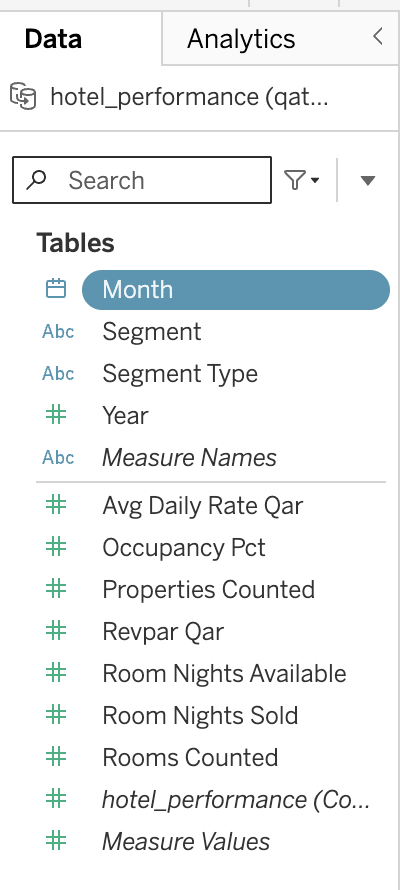

The pane is split into two groups by a faint grey horizontal line - **Dimensions** & **Measures**


| Where | What it means | What is there |
|---|---|---|
| **Above the line** | **Dimensions** — things you can *group by* | `Month` · `Segment` · `Segment Type` · `Year` |
| **Below the line** | **Measures** — things you can *do arithmetic on* | `Avg Daily Rate Qar` · `Occupancy Pct` · `Properties Counted` · `Revpar Qar` · `Room Nights Available` · `Room Nights Sold` · `Rooms Counted` |

The italic entries — `Measure Names`, `Measure Values`, `hotel_performance (Count)` — are built by Tableau, not
by your file. Ignore them today.

Tableau sorted your columns into those two groups by guessing each one's **type**. However, you are about to watch Tableau guess wrong, and that demands human expertise.

---

# Part 1 · Build the First Chart


## Step 4 · Build it

1. Drag **`Segment`** to **Rows**.
2. Drag **`Room Nights Sold`** to **Columns**.

You get a bar chart immediately. It looks completely fine.

**Look at it properly.** There are seven bars. One of them, `Qatar (all accommodation)`, is roughly as long as the
other six put together.

## Step 5 · Find out why

Click anywhere empty, then drag **`Segment Type`** to **Rows**, above `Segment`. Now you can see it:

| `Segment Type` | `Segment` |
|---|---|
| **Hotel segment** | 1 & 2 Star Hotels · 3 Star Hotels · 4 Star Hotels · 5 Star Hotels · Deluxe Apartments · Standard Apartments |
| **Whole market** | Qatar (all accommodation) |

`Qatar (all accommodation)` is **not a seventh kind of hotel.** It is the published total of the other six,
stored in the same column. Your chart added the total to its own parts.


Nothing was broken. Tableau did exactly what you asked. **You asked the wrong question**, and the chart answered
it confidently, in a professional typeface, in four seconds.

> ### If you try to check the arithmetic, it will not work — and that is also true
> The total is *published by Qatar Tourism*, not computed from the six categories. Add the six yourself and you
> get a number **0.43% larger**; across the 135 months the gap runs from −0.108% to +1.513% and **not one month
> matches exactly.** You can neither sum the parts to get the total nor reconcile them.
>
> So the fix is not "remove the total because it is redundant". It is **"these are two different measurements of
> the same thing, and you must pick one."** We pick the published total.

> **This is the whole course in one chart.** Every tool you will ever use is this willing to be wrong for you.

## Step 6 · Fix it

Drag **`Segment Type`** to the **Filters** shelf → tick **`Hotel Segment`** only → OK.

Remove `Segment Type` and `Segment` from Rows. You now have one honest number for the country if you hover above the bar.

> ### A panel just appeared on the right. That is supposed to happen.
> In Tableau's browser editor, **dropping a field on Filters automatically gives you an interactive filter
> card.** You did not ask for it and you cannot stop it. Leave it alone for now — in Part 5 you will learn to
> tune it, and to hide the ones you do not want strangers clicking.
>
> ⚠️ **Do not switch that card to `Hotel segment`.** It silently puts the double-count back.


---

# Part 2 · The price

## Step 7 · Put time on the bottom — and meet blue and green

Remove everything in Columns, Rows, and Filter

Drag **`Month`** to **Columns**.


**What you should see:** twelve column headers — 2014, 2015, … 2025 — each with a small grey **`Abc`**
underneath. **No bars, and that is correct.** You have told Tableau *how to slice* the data but not *what to
show*, so there is nothing yet to draw. The measure arrives in Step 8.

Look at the pill. It is **blue**, and it says `YEAR(Month)`.

**Click the small ▾ on the right-hand edge of the pill — one click.** A long menu opens. Scroll down and you will see the words *Year, Quarter, Month, Day* appear **twice, in two separate blocks**. That is not a bug, and the
blocks are not labelled — **the only way to tell them apart is the example value printed on the right:**

| Block | Its `Month` row reads | What Tableau will do |
|---|---|---|
| **Upper** | `May` | Treat the date as a **category** — the month-of-year. All eleven Mays collapse into one column. |
| **Lower** | `May 2015` | Treat the date as a **point in time** — 135 separate months along a continuous axis. |

**Choose `Month` from the lower block — the one reading `May 2015`.**

> ### Why the lab keeps saying "blue and green"
> Look at the pill now: it has turned **green**. Nothing in the menu was coloured — the colour is Tableau
> *reporting back* what you chose. Blue = a category. Green = a position on a scale. You cannot pick by colour;
> you pick by meaning, and the colour confirms it afterwards.


> ### If you double-click the pill by mistake
> It turns into a formula box reading `DATEPART('year', [Month])`. That is the pill's underlying expression,
> not an error — press **Esc** to leave it untouched, then click the **▾** instead.

> This column is stored as a date *and time*, so the menu also offers Hour, Minute and Second. Ignore them —
> every value in this file is midnight on the first of the month.

**What you should see:** the twelve separate headers collapse into one **continuous date axis** running
2014 → 2025. Still no marks — that is still Step 8's job. The axis itself is the thing that changed.

> ### Say this to yourself
> **"Blue means Tableau is treating this as a category. Green means it is treating it as a number on a scale.
> Same column. Two types. Two completely different charts — and I chose."**


You get **twelve fat bars** — one per year, 2014 through 2025. That is not what you wanted. Look at the pill:
it is **blue**, and it says `YEAR(month)`.

Double Click the pill. A menu opens with the word *Year* appearing **twice**. That is not a bug:

| | |
|---|---|
| The **top** block (blue) | Tableau treats the date as a **category**. "Year" is a label, like "5 Star Hotels". |
| The **bottom** block (green) | Tableau treats the date as a **position on a number line**. |

Choose **Month** from the **bottom, green** block — the one under *Year / Quarter / Month / Day*, not the one
near the top.

> This column is stored as a date *and time*, so the menu also offers Hour, Minute and Second. Ignore them —
> every value in this file is midnight on the first of the month.

**What you should see:** a continuous time axis running 2014 → 2025, 135 months.

> ### Say this to yourself
> **"Blue means Tableau is treating this as a category. Green means it is treating it as a number on a scale.
> Same column. Two types. Two completely different charts — and I chose."**

## Step 8 · Add the price, and catch the second lie

Drag **`Avg Daily Rate Qar`** to **Rows**.

The pill says **`SUM(avg_daily_rate_qar)`**.

**That is meaningless.** `Avg Daily Rate Qar` is a *price*. Adding January's room rate to February's room rate
produces a number that corresponds to nothing in the world.

Click the pill → **Measure** → **Average**.

> ### Say this out loud
> **"You can add room-nights. You cannot add prices."**
>
> This file has both kinds of column, side by side. `Room Nights Sold` is a **count** — adding it is correct.
> `Occupancy Pct`, `Avg Daily Rate Qar` and `Revpar Qar` are **ratios** — adding them is nonsense. Tableau
> defaults to `SUM` for all seven and will never warn you.
>
> **Check this on every measure you drag, for the rest of your life.**

## What you are now looking at

A flat line for eight years, then a cliff.

| Month | Avg daily rate (QAR) |
|---|---|
| 2022-10 | 456.61 |
| **2022-11** | **1,839.25** |
| **2022-12** | **2,103.59** |
| 2023-01 | 423.61 |

**4.6× in two months, and then −79.9% in one.** January 2023 is *below* where October 2022 started.

Rename the sheet (double-click the tab at the bottom): **`Price`**

---

# Part 3 · The emptiness
### 26–34 minutes

The obvious story is "Qatar made a fortune." Now test it.

## Step 9 · Add a second pane

Drag **`Occupancy Pct`** to **Rows**, and drop it **next to** the existing `AVG(avg_daily_rate_qar)` pill —
an ordinary drop onto the Rows shelf, beside the pill that is already there.

Change it to **Average** the same way (click pill → Measure → Average).

You now have **two charts stacked, sharing one time axis.** Price on top, occupancy underneath.

> **Why not a dual axis?** Because putting two different scales on one chart is the single easiest way to lie with
> a line, and because the drop target for it is three pixels wide and you would spend five minutes missing it.
> Two panes tell the identical story and cannot be rigged. (Fast finishers: see the stretch at the end.)

## What you should see — and this is the point of the lab

The price line goes through the roof. **The occupancy line barely moves.**

| Qatar, whole market | Oct 2022 | Nov 2022 | Dec 2022 | Jan 2023 |
|---|---|---|---|---|
| Avg daily rate (QAR) | 456.61 | 1,839.25 | 2,103.59 | 423.61 |
| **Occupancy** | **55.1%** | **55.9%** | **59.7%** | **46.3%** |

Now rank every November in the file by occupancy:

| | Nov | Occupancy |
|---|---|---|
| 🔻 **lowest** | **2022 — the World Cup** | **55.9%** |
| | 2017 | 60.7% |
| | **2020 — the pandemic** | **61.0%** |
| | 2018 | 67.0% |
| | 2015 | 69.7% |
| | 2016 | 69.8% |
| | 2021 | 70.7% |
| | 2023 | 71.0% |
| | 2019 | 71.8% |
| | 2024 | 83.3% |
| highest | 2014 | 84.5% |

> ### Qatar's hotels were emptier during the World Cup than during the pandemic.
> **44% of the country's rooms sat empty** in the month the world arrived — 496,081 unsold room-nights.

**Why?** Because Qatar built the rooms anyway. `Room Nights Available` went **994,697 → 1,124,160 → 1,162,345**
in three months — about 17% more capacity. Occupancy stayed flat because supply rose as fast as demand did.

> **This is Lab 1's lesson again.** In Lab 1 you changed two numbers and a dashboard about Doha became a dashboard
> about Pittsburgh — *a chart of a plan is not a chart of the world.* Here is the same idea with money in it: the
> plan was a full country; the world was a 4.6× price spike in half-empty buildings.

Rename this sheet: **`Price vs Occupancy`**

**✋ STOP — show a TA both panes.**

---

# Part 4 · Who paid
### 34–42 minutes

Two charts answer *what happened to the country*. Neither tells you **who**.

## Step 10 · A third view, a different shape

1. New sheet (the **+** at the bottom).
2. Drag **`Segment Type`** to **Filters** → this time tick **`Hotel segment`** only (the six real categories).
3. Drag **`Month`** to **Filters** → **Range of Dates** → set it to **December 2022** only.
   *(If the dialog offers Years/Months/Days, choose Months, then pick December 2022.)*
4. Drag **`Segment`** to **Rows**.
5. Drag **`Avg Daily Rate Qar`** to **Columns** → change to **Average**.
6. Click the **Sort descending** button on the toolbar.

## What you should see

| Segment, Dec 2022 | Avg daily rate | Occupancy |
|---|---|---|
| 5 Star Hotels | **3,081.65** | 56.7% |
| Deluxe Apartments | 1,655.47 | 60.5% |
| Standard Apartments | 1,358.57 | 50.3% |
| 4 Star Hotels | 1,088.79 | 61.0% |
| 3 Star Hotels | 778.96 | 75.4% |
| 1 & 2 Star Hotels | **423.84** | **87.7%** |

**The expensive rooms were the empty ones.** Five-star hotels charged 7.3× what the cheapest did and still ran at
56.7%. The 1&2-star segment charged 423.84 QAR — almost exactly Qatar's *normal* price — and ran nearly full.

> One word, "hotel", covering two completely different businesses. **Every category label you ever put on an axis
> is hiding something like this.**

Rename: **`Who Paid`**

> **You now have three views that answer three different questions** — change over time, two measures compared,
> and a ranked comparison across categories. Project 2 asks for three. This is what three looks like.

## Step 10b · A fourth view — the whole decade at once

Three charts, three shapes: a line, two panes, a bar. Now a **highlight table** — a grid where the *colour of
each cell* is the number. It is the densest chart in the lab: 72 values on one screen.

1. New sheet (**+** at the bottom).
2. Drag **`Segment Type`** to **Filters** → tick **`Hotel segment`** only → OK. *(The six real categories — we
   want the components here, not the country total.)*
3. Drag **`Month`** to **Columns**. Click the pill's **▾** → this time choose **`Year`** from the **UPPER**
   block — the one whose example reads `2015`, not `Q2 2015`.
4. Drag **`Segment`** to **Rows**.
5. On the **Marks** card, change the mark type dropdown from *Automatic* to **Square**.
6. Drag **`Occupancy Pct`** onto the **Colour** square on the Marks card. Click it → **Measure → Average**.
7. Drag **`Occupancy Pct`** onto the **Text** square too. Click it → **Measure → Average**.

### Why the upper block this time

In Step 7 you deliberately chose the **lower** block to get a continuous axis. Here you want the opposite:
**twelve discrete columns**, one per year, each a labelled box. Same menu, opposite choice — because this time
the question is "compare these twelve buckets", not "show me a trend through time".

**The same field can be two different things. You decide which, every single time.**

### What you should see

A 6 × 12 grid of coloured squares. Two things should be visible from across the room:

- **Cold vertical bands in 2016–17 and again in 2020** — every segment empties at once. Something happened to
  the whole country, twice.
- **A split that widens left to right.** `1 & 2 Star Hotels` climbs 81 → 88 → 89. `Deluxe Apartments` falls
  87 → 52. The cheap rooms fill up; the expensive ones empty out.

That is the "Who Paid" story again — but that chart showed one month, and this shows twelve years.

> ### Leave the colours alone
> Tableau gives you a **single-hue** scale, pale to dark. Keep it. A red-to-blue scale would look fancier, and
> it would be **wrong**: red-to-blue means *"there is a meaningful middle and two opposite directions"*. There
> is no natural midpoint for occupancy — 60% is not neutral. One hue, light to dark, for one quantity.
>
> **The fancier-looking choice is the wrong one here.** That will keep being true.

> ### One caveat to put under your chart
> The **2025 column covers January to March only** — the file stops there. `1 & 2 Star` reads 94% for 2025, but
> that is three winter months, not a year. A chart that shows it beside twelve full years invites a comparison
> the data cannot support.


---

# Part 5 · Make it interactive
### 42–54 minutes

**This part is what Project 2 is actually graded on.** A view is interactive when *a person who is not you can
change what it shows.* If the only way to see something different is to ask you to rebuild it, it is not
interactive.

> **Tableau's browser editor gives you interactivity whether you asked for it or not** — every field you drop
> on Filters becomes a control a stranger can click. So the work here is not switching it on. It is **choosing
> what to expose, and what to lock down.**

## Step 11 · You already have a filter. Make it useful.

Go back to your **`Price vs Occupancy`** sheet.

Look right. **The `Segment Type` card from Part 1 is already sitting there** — the browser gave it to you the
moment you dropped the field on Filters. Half the work of "make it interactive" was done for you and nobody
said so.

So the real skills are the two Tableau never does for you: **adding a second filter**, and **controlling what
a stranger can touch.**

### Add a second filter

Drag **`Year`** — it is above the line, with the dimensions — to the **Filters** shelf. Tick every year → OK.

A second card appears on the right, automatically. You did not ask for it. You never will.

> **If Tableau gives you a slider instead of a tick-list**, it has decided `Year` is a number rather than a
> label. Remove it, and drag **`Month`** to Filters instead → choose **Years** → **Next** → tick all → OK.
> Same result, and the same lesson as the blue/green pill: **the type decides what the field can do.**

### Tune the cards

Click the small **▾** at the top-right of the year card → **Single Value (dropdown)**. It collapses from a tall
tick-list into one compact control — which matters, because this card is going on the internet in ten minutes.

## Step 12 · Play with it — then decide what to leave out

Change the year. Watch both panes redraw. **You did not rebuild anything.** That is the entire concept, and it
is the difference between a picture and a tool.

### Now hide one

Open the **▾** on the `Segment Type` card and untick **Show Filter**.

The card disappears; **the filter is still applied.** Your numbers stay correct and a stranger can no longer
switch it to `Hotel segment` and silently double your chart.

> ### This is the browser-specific skill, and it is the one worth keeping
> In the browser Tableau hands you a card for every filter, so the question is never *"how do I show one?"* —
> it is **"which of these am I willing to let a stranger change?"**
>
> Leave the year card visible: exploring by year is the point. Hide `Segment Type`: changing it only breaks the
> chart. **Interactivity is something you grant deliberately, not everything you forgot to take away.**

---

# Part 6 · Dashboard and Story
### 54–63 minutes

Project 2's prompt says *"a Tableau **story**."* That is not a figure of speech — **Story is a specific object
with its own tab button.** Meet both now so you are not meeting them alone at home on 14 November.

## Step 13 · Dashboard — one page, several charts

Click the **New Dashboard** icon at the bottom (next to the new-sheet **+**).

Drag **`Price vs Occupancy`** and **`Who Paid`** from the left onto the canvas.

That is it. **A dashboard is one page with more than one chart on it.** Your filters come along.

> If a chart appears tiny or squashed, set **Size → Automatic** in the left panel.

## Step 14 · Story — a sequence with captions

Click the **New Story** icon.

1. Drag **`Price`** onto the canvas. Click the caption box above it and type what the reader should notice:
   *"Room rates went up 4.6× in two months."*
2. Click **Blank** to add a second story point. Drag **`Price vs Occupancy`** in. Caption:
   *"But the rooms were emptier than during the pandemic."*
3. Add a third. Drag **`Who Paid`** in. Caption: *"The expensive rooms were the empty ones."*

**That is a data story**: an ordered sequence of views, each with a sentence telling the reader what to see.
Three story points, three claims, one argument.

> **Your captions should state a finding, not name a variable.** "Average daily rate by month" tells the reader
> nothing they cannot see. "Room rates went up 4.6× in two months" tells them why to look.

---

# Part 7 · Publish, and check it like a stranger
### 63–72 minutes

**This is the most important ten minutes of the lab.** Do not let the clock eat it.

## Step 15 · Publish

Click the blue **Publish As…** button at the top right → name it `67290 Lab 2 — <your name>` → publish.

Remember what Step 2 told you: **this is the save button, and it saves to the internet.**

## Step 16 · Open it as a stranger would

> ### ⚠️ Do not copy the link out of your address bar
> While you are editing, the address bar holds an **`/authoring/`** URL. It reopens *the editor*, and only for
> you. Hand that to a TA and it proves nothing. Tableau's own instruction is to get the link from the
> **published view**, not the editor.

1. Click your **avatar → My Profile** — or the workbook name — to **leave the editor** and land on the
   published view.
2. At the **bottom of the view**, click **Share** → **Copy Link**.
3. **Open a brand-new tab.** Paste it. *(Even better: open it on your phone.)*
4. **Click your filters, there.**

> ### Why this step and not the editor
> Until you have seen your own filters work on a page that is **not** the editor you built them in,
> "interactive" is a word on a rubric. This is also exactly what the TA sees when grading you — so you are
> looking at the grader's screen.

**If the year card is missing in the new tab**, you hid the wrong one in Step 12. Go back, re-show it, Save again.

**✋ STOP — show a TA your published viz in a fresh tab, with the filter working.**

This is the one checkpoint that matters. If you get no further today, you can still do Project 2.

---

# Part 8 · The mess
### 72–85 minutes

Everything so far used a file chosen because it is spotless: 945 rows, zero blanks, every column already the right
type, not one Arabic character.

**No file you meet in Project 2 is like that.** Here is one that is not.

## Step 17 · Upload it

New workbook: **Create → Web Authoring → Connect to Data → Files → Upload from Computer** →
`data/qatar-museum-visitors-2013-2024.xlsx`.

Qatar Museums visitor counts, 2013–2024. 1,372 rows, 6 columns.

## Step 18 · Find the first problem yourself

Look at the field lists. You want to chart **how many people visited.** The column is called `Number`.

**It is above the line, with the dimensions — not below it with the measures.**

Tableau read that column as **text**, so it will not let you do arithmetic on it. Why?

Because **95 of its 1,372 cells are not numbers**:

| What the cell says | How many | What it means |
|---|---|---|
| `--` | 60 | *not recorded* |
| `-` | 26 | *not recorded, written differently* |
| `مغلق` | 4 | **the museum was closed** |
| `مغلق للتجديد Closed For Renovation` | 4 | **closed for renovation** |
| `يفتح للزوار الرسميين Only Open To Official Visitors` | 1 | open, but not to you |

One text cell in a column of 1,372 numbers is enough. Tableau cannot store "27,431" and "مغلق" as the same type,
so it makes the whole column text.

## Step 19 · Fix it

In the **Data** pane, click the small type icon (**Abc**) to the left of `Number` → choose **Number (whole)**.

`Number` drops below the line, in with the measures. You can chart it now.

> ### But look at what you just did
>
> Those 95 cells are now **Null**. They vanish from every chart you build.
>
> And they were not all the same thing. `--` means *nobody wrote the number down*. `مغلق` means *the museum was
> shut that month*. The first is a gap in the record. **The second is a fact about the world** — and you have just
> deleted it.
>
> A visitor-numbers chart built on this file, without a word of explanation, quietly reports that Al-Khor Regional
> Museum had a bad few years. It did not. **It was closed.**
>
> The fix is not technical. It is one sentence under your chart saying which months are missing and why. That
> sentence is worth more than the chart.

## Step 20 · The second problem — one museum, many names

Drag **`Museum`** to **Rows** and **`Number`** to **Columns**.

Count the bars: **32**. Qatar does not have 32 museums here. Look:

```
3-2-1 QOSM   ·   321 QOSM   ·   QOSM   ·   Expo - 3-2-1 QOSM Activities
AL-Khor Regional  (M.Arch & Ethnog)   ·   AL-Khor Regional  (M.Arch & Ethnog)*   ·   AL-Khor Regional M.Arch &    Ethnog
M7   ·   M7*            DADU Gardens   ·   DADU Gardens *
```

Same museums. Different spellings — extra spaces, a trailing `*`, a prefix. **Every chart you group by `Museum`
splits one museum into three and makes each look small.**

**Fix it:** in the view, **ctrl-click (⌘-click on Mac) to select the three `AL-Khor Regional` bars**, then click
the **paperclip 📎 (Group Members)** icon on the tooltip that appears. They merge into one.

> **While you are here, notice one more thing:** the years run 2013, 2014, 2015, **2017**, 2018… **2016 is not in
> this file at all.** Nothing in Tableau will tell you that. Only counting will.

> ### What to take to Project 2
> Before you build a single chart, ask three questions:
> 1. **Is every column the type I expect?** (If something countable sits *above* the line, something is wrong.)
> 2. **What is missing, and does the missing mean something?**
> 3. **Is the same real thing written more than one way?**

---

# Part 9 · Submit
### 85–90 minutes

Submit on Canvas:

1. **The URL of your published hotel viz** — the dashboard or the story. Open it in a fresh tab first and check it
   loads and the filters work.
2. **One sentence** naming something your chart cannot tell the reader.

That second item is not a formality. Every chart you made today hides something — the segments inside the whole
market, the months outside the filter, the reason the rooms were empty. Name one.

## Grading · 5 points

| | |
|---|---|
| 2 | A published viz at a working URL, with at least two views |
| 1 | A working filter card on the published page — **opened from Share, not the editor's address bar** |
| 1 | The `Segment Type` filter is applied — your numbers are not doubled |
| 1 | The sentence naming what the chart cannot say |

**Participation-shaped.** If you hit a wall, said so, and showed a TA what you tried, you keep full marks. A
half-finished viz with an honest sentence beats a polished one built on doubled numbers.

---

## Project 2 is now out

**"Qatar in Data" · 20 points · individual · due Monday 16 November, 11:00pm**

A Tableau **story** with **≥ 3 interactive views** and a 300–500 word reflection, built on a dataset from the
course menu — **not** the hotel file, and not the museum file. Both have been walked through in class.

Sign up for your dataset today — **maximum 4 students per dataset**, first come.

> **You already know how to do all of it.** Upload a file · check every column's type · fix the ones Tableau got
> wrong · change `SUM` to `AVG` on anything that is a ratio · build three views that answer three different
> questions · Show Filter · assemble a Story · publish · check it in a fresh tab.
>
> That list is this lab. Keep this notebook open while you do it.

> 🌡️ **If you pick a dataset marked 🌡️ on the menu, your Final Project can continue the same story with the same
> data.** That is the cheapest path through November and it is allowed.

---

## Troubleshooting

| What you see | What happened | Fix |
|---|---|---|
| Numbers look about twice as big as they should | No `Segment Type` filter — you are adding the total to its parts | Filter `Segment Type` to `Whole market` |
| Twelve fat bars instead of a time line | `Month` is a blue discrete `YEAR` pill | Click the pill → choose **Month** from the lower, **green** block |
| Prices look enormous / impossible | Tableau defaulted to `SUM` on a ratio | Click the pill → **Measure → Average** |
| A filter card appeared that you never asked for | Normal — the browser adds one for **every** field you drop on Filters | Leave it, or hide it: card **▾** → untick **Show Filter** |
| Your link reopens the editor instead of the chart | You copied an **`/authoring/`** URL out of the address bar | Leave the editor → open the published view → **Share** at the bottom → **Copy Link** |
| A stranger can break your chart | You left the `Segment Type` card visible and they switched it | Card **▾** → untick **Show Filter**, then Save again |
| `Number` sits above the line, with the dimensions | 95 cells contain text, not numbers | Click the **Abc** icon → **Number (whole)** |
| Can't save at all | Email never confirmed | Check spam, then ask a TA for a spare account |
| Working on an iPad | Tableau does not support authoring on mobile, at all | Borrow a laptop — ask a TA now |

---

## If you finish early

**1 · Abuse a dual axis.** On `Price vs Occupancy`, make it a dual axis instead of two panes, then right-click each
axis → Edit Axis and change the ranges by hand. You can make the same two series look correlated, uncorrelated, or
inverted — **without changing one number.** That is the most famous chart lie there is, and it is two clicks away.
Screenshot two opposite-looking versions and bring them to Wednesday's class.

**2 · Find the other total.** `Room Nights Available`, `Properties Counted` and `Rooms Counted` have the same
total-inside-the-parts problem. Prove it.

**3 · The take-home.** Put your viz inside the Observable dashboard you built in Lab 1:
[`TAKE-HOME-embed-in-observable.md`](./TAKE-HOME-embed-in-observable.md). Optional, ungraded, genuinely useful for
the Final Project — which requires a Tableau chart embedded in an ArcGIS StoryMap.